# 1. Installation

## 1.1 Python modules

In [1]:
import sys

if 'google.colab' in sys.modules:
    !pip install obspy obsplus pyproj segyio

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.5/14.5 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 344.3/344.3 kB 19.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.1/85.1 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 57.0 MB/s eta 0:00:00
  Attempting uninstall: sqlalchemy
    Found existing installation: SQLAlchemy 2.0.41
    Uninstalling SQLAlchemy-2.0.41:
      Successfully uninstalled SQLAlchemy-2.0.41
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython-sql 0.5.0 requires sqlal

## 1.2. Clone Field Camp II Library (fc2)

In [1]:
!git clone https://github.com/ecastillot/FieldCampII_2025.git /content/FieldCampII_2025

Cloning into '/content/FieldCampII_2025'...
remote: Enumerating objects: 572, done.
remote: Counting objects: 100% (333/333), done.
remote: Compressing objects: 100% (196/196), done.
remote: Total 572 (delta 180), reused 260 (delta 109), pack-reused 239 (from 1)
Receiving objects: 100% (572/572), 663.44 MiB | 21.92 MiB/s, done.
Resolving deltas: 100% (223/223), done.


In [1]:
import sys
lib = "/content/FieldCampII_2025"
sys.path.append(lib)

# 1.3. Test

In [22]:
import datetime
from obspy import UTCDateTime # obspy
from fc2.seismic import read_shots_from_folder,plot_shot_data #fc2

# 2. Download data

Change the dropbox path to download the shots data

In [3]:
!wget -O project.zip "https://www.dropbox.com/scl/fo/8p6cqo5rr6qwaxpyn4zx9/AOiirDBEIFrZqV0-EMqkgzQ?rlkey=nwz9kl2hyyhlu2bkuqps1qdwo&dl=1"
!unzip  project.zip -d  project

--2025-07-15 22:23:53--  https://www.dropbox.com/scl/fo/8p6cqo5rr6qwaxpyn4zx9/AOiirDBEIFrZqV0-EMqkgzQ?rlkey=nwz9kl2hyyhlu2bkuqps1qdwo&dl=1
Resolving www.dropbox.com (www.dropbox.com)... 162.125.5.18, 2620:100:601d:18::a27d:512
Connecting to www.dropbox.com (www.dropbox.com)|162.125.5.18|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://ucb5bdf24bfeb0c77876e720e82a.dl.dropboxusercontent.com/zip_download_get/CQ9RLGWmVT_wR8LToXb_3YE1oCfMWcwZ2ifcxF6JCSf_mZHWwkZ7KS4GnFdwYWq9NB-Q1WYcOxbLfIe2oAAmQhXO7Y1l2FnPlW6NgwMnZSmgKA# [following]
--2025-07-15 22:23:54--  https://ucb5bdf24bfeb0c77876e720e82a.dl.dropboxusercontent.com/zip_download_get/CQ9RLGWmVT_wR8LToXb_3YE1oCfMWcwZ2ifcxF6JCSf_mZHWwkZ7KS4GnFdwYWq9NB-Q1WYcOxbLfIe2oAAmQhXO7Y1l2FnPlW6NgwMnZSmgKA
Resolving ucb5bdf24bfeb0c77876e720e82a.dl.dropboxusercontent.com (ucb5bdf24bfeb0c77876e720e82a.dl.dropboxusercontent.com)... 162.125.5.15, 2620:100:601d:15::a27d:50f
Connecting to ucb5bdf24bfeb0c77876e720e82a.dl.d

# 3. Read data

## 3.1 Shots

In [4]:
help(read_shots_from_folder)

Help on function read_shots_from_folder in module fc2.seismic:

read_shots_from_folder(folder_path: str, gps_start=None, source_time_separation=None, bad_shots=None, debug=False) -> pandas.core.frame.DataFrame
    Reads all shot files in a specified folder and merges them into a single DataFrame.
    Parameters
    ----------
    folder_path : str
        Path to the folder containing shot files.
    gps_start : datetime.datetime or None
        The GPS epoch start time. If None, defaults to January 6, 1980.
    source_time_separation : dict
        The maximum time separation between shots to consider them part of the same group (in seconds).
        example: {"P1": 76.45, "S1_N": 21, ...}
    bad_shots : list or None
        A list of shot groups to exclude from the final DataFrame. If None, all shots are included.
    debug : bool
        If True, prints debug information during processing.
    Returns
    -------
    pd.DataFrame
        A DataFrame containing all shots, sorted by 

In [26]:
project_folder = "/content/project"
starttime = datetime.datetime(2025,6,14,14,0)  ## CHANGE YOUR STARTTIME OR ENDTIME
endtime = datetime.datetime(2025,6,14,15,40)

shots = read_shots_from_folder(project_folder)
shots = shots[shots['time'] >= starttime]
shots = shots[shots['time'] <= endtime]
display(shots)


Group 'last_group' with 650 shots


/content/FieldCampII_2025/fc2/seismic.py:509: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  gd_shots = pd.concat([gd_shots, bad_shots]).reset_index(drop=True)


,shot_group,shot,time,time_from_group_lead,year,month,day,hour,minute,second,latitude,longitude
0,last_group,1,2025-06-14 14:00:18.890,0.00,2025,6,14,14,0,18.89,27.63189,-97.20664
1,last_group,2,2025-06-14 14:00:49.290,30.40,2025,6,14,14,0,49.29,27.63189,-97.20664
2,last_group,3,2025-06-14 14:01:01.980,43.09,2025,6,14,14,1,1.98,27.63189,-97.20664
3,last_group,4,2025-06-14 14:01:16.580,57.69,2025,6,14,14,1,16.58,27.63189,-97.20664
4,last_group,5,2025-06-14 14:01:25.300,66.41,2025,6,14,14,1,25.30,27.63189,-97.20665
...,...,...,...,...,...,...,...,...,...,...,...,...
285,last_group,286,2025-06-14 15:33:45.200,5606.31,2025,6,14,15,33,45.20,27.63223,-97.20693
286,last_group,287,2025-06-14 15:33:49.160,5610.27,2025,6,14,15,33,49.16,27.63223,-97.20693
287,last_group,288,2025-06-14 15:33:53.250,5614.36,2025,6,14,15,33,53.25,27.63223,-97.20693
288,last_group,289,2025-06-14 15:33:57.000,5618.11,2025,6,14,15,33,57.00,27.63223,-97.20693


We need to label each group

In [27]:
display(shots.iloc[0:15])

,shot_group,shot,time,time_from_group_lead,year,month,day,hour,minute,second,latitude,longitude
0,last_group,1,2025-06-14 14:00:18.890,0.00,2025,6,14,14,0,18.89,27.63189,-97.20664
1,last_group,2,2025-06-14 14:00:49.290,30.40,2025,6,14,14,0,49.29,27.63189,-97.20664
2,last_group,3,2025-06-14 14:01:01.980,43.09,2025,6,14,14,1,1.98,27.63189,-97.20664
3,last_group,4,2025-06-14 14:01:16.580,57.69,2025,6,14,14,1,16.58,27.63189,-97.20664
4,last_group,5,2025-06-14 14:01:25.300,66.41,2025,6,14,14,1,25.30,27.63189,-97.20665
5,last_group,6,2025-06-14 14:01:35.510,76.62,2025,6,14,14,1,35.51,27.63189,-97.20665
6,last_group,7,2025-06-14 14:07:27.450,428.56,2025,6,14,14,7,27.45,27.63192,-97.20667
7,last_group,8,2025-06-14 14:07:33.960,435.07,2025,6,14,14,7,33.96,27.63192,-97.20667
8,last_group,9,2025-06-14 14:07:37.730,438.84,2025,6,14,14,7,37.73,27.63192,-97.20667
9,last_group,10,2025-06-14 14:07:57.520,458.63,2025,6,14,14,7,57.52,27.63193,-97.20667


In [31]:
source_time_separation = { #P Wave
                              "P1": 77}
shots = read_shots_from_folder(project_folder,
                               source_time_separation = source_time_separation,
                               debug=True)
shots = shots[shots['time'] >= starttime]
shots = shots[shots['time'] <= endtime]
display(shots.iloc[0:16])

Total shots read: 650

Group P1 started at 2025-06-14 14:00:18.890000 with 6 shots
   shot                    time  time_from_group_lead shot_group
0     1 2025-06-14 14:00:18.890                  0.00         P1
1     2 2025-06-14 14:00:49.290                 30.40         P1
2     3 2025-06-14 14:01:01.980                 43.09         P1
3     4 2025-06-14 14:01:16.580                 57.69         P1
4     5 2025-06-14 14:01:25.300                 66.41         P1
5     6 2025-06-14 14:01:35.510                 76.62         P1

Group 'last_group' with 644 shots
     shot                    time  time_from_group_lead  shot_group
0       7 2025-06-14 14:07:27.450                  0.00  last_group
1       8 2025-06-14 14:07:33.960                  6.51  last_group
2       9 2025-06-14 14:07:37.730                 10.28  last_group
3      10 2025-06-14 14:07:57.520                 30.07  last_group
4      11 2025-06-14 14:08:02.050                 34.60  last_group
..    ...          

,shot_group,shot,time,time_from_group_lead,year,month,day,hour,minute,second,latitude,longitude
0,P1,1,2025-06-14 14:00:18.890,0.00,2025,6,14,14,0,18.89,27.63189,-97.20664
1,P1,2,2025-06-14 14:00:49.290,30.40,2025,6,14,14,0,49.29,27.63189,-97.20664
2,P1,3,2025-06-14 14:01:01.980,43.09,2025,6,14,14,1,1.98,27.63189,-97.20664
3,P1,4,2025-06-14 14:01:16.580,57.69,2025,6,14,14,1,16.58,27.63189,-97.20664
4,P1,5,2025-06-14 14:01:25.300,66.41,2025,6,14,14,1,25.30,27.63189,-97.20665
5,P1,6,2025-06-14 14:01:35.510,76.62,2025,6,14,14,1,35.51,27.63189,-97.20665
6,last_group,7,2025-06-14 14:07:27.450,0.00,2025,6,14,14,7,27.45,27.63192,-97.20667
7,last_group,8,2025-06-14 14:07:33.960,6.51,2025,6,14,14,7,33.96,27.63192,-97.20667
8,last_group,9,2025-06-14 14:07:37.730,10.28,2025,6,14,14,7,37.73,27.63192,-97.20667
9,last_group,10,2025-06-14 14:07:57.520,30.07,2025,6,14,14,7,57.52,27.63193,-97.20667


In [35]:
source_time_separation = { #P Wave
                              "P1": 77,
                              "P2":40,
                              "P3":30,
                              "P4":42,
                              "P5":46,
                              "P6":26,
                              "P7":22,
                              "P8":30,
                              "P9":33,
                              "P10":33,
                              "P11":23,
                              "P12":24,
                              "P13":27,
                              "P14":62,
                              "P15":51,
                              "P16":30,
                              #S Wave
                              "S1_N":21,
                              "S1_S":21,
                              "S2_N":20,
                              "S2_S":24,
                              "S3_N":31,
                              "S3_S":38,
                              "S4_N":36,
                              "S4_S":30,
                              "S5_N":31,
                              "S5_S":21,
                              "S6_N":26,
                              "S6_S":20,
                              "S7_N": 21,
                              "S7_S": 22,
                              "S8_N": 21,
                              "S8_S": 29,
                              "S9_N": 21,
                              "S9_S": 24,
                              "S10_N": 30,
                              "S10_S": 36,
                              "S11_N": 23,
                              "S11_S": 22,
                              "S12_N": 22,
                              "S12_S": 27,
                              "S13_N": 36,
                              "S13_S": 24,
                              "S14_N": 29,
                              "S14_S": 21,
                              "S15_N": 22,
                              "S15_S": 22,
                              "S16_N": 25,
                              "S16_S": 20,
                            }
bad_shots=[181,182]

shots = read_shots_from_folder(project_folder,
                               bad_shots=bad_shots,
                               source_time_separation = source_time_separation)
shots = shots[shots['time'] >= starttime]
shots = shots[shots['time'] <= endtime]
display(shots.iloc[0:16])


Group P1 started at 2025-06-14 14:00:18.890000 with 6 shots

Group P2 started at 2025-06-14 14:07:27.450000 with 6 shots

Group P3 started at 2025-06-14 14:09:28.790000 with 6 shots

Group P4 started at 2025-06-14 14:10:46.480000 with 6 shots

Group P5 started at 2025-06-14 14:11:59.200000 with 6 shots

Group P6 started at 2025-06-14 14:13:22.290000 with 6 shots

Group P7 started at 2025-06-14 14:14:20.570000 with 6 shots

Group P8 started at 2025-06-14 14:15:11.560000 with 6 shots

Group P9 started at 2025-06-14 14:16:11.180000 with 6 shots

Group P10 started at 2025-06-14 14:17:30.630000 with 6 shots

Group P11 started at 2025-06-14 14:18:37.870000 with 6 shots

Group P12 started at 2025-06-14 14:19:24.250000 with 6 shots

Group P13 started at 2025-06-14 14:20:16.440000 with 6 shots

Group P14 started at 2025-06-14 14:25:26.450000 with 6 shots

Group P15 started at 2025-06-14 14:28:41.210000 with 6 shots

Group P16 started at 2025-06-14 14:31:57.630000 with 6 shots

Group S1_N start

,shot_group,shot,time,time_from_group_lead,year,month,day,hour,minute,second,latitude,longitude
0,P1,1,2025-06-14 14:00:18.890,0.00,2025,6,14,14,0,18.89,27.63189,-97.20664
1,P1,2,2025-06-14 14:00:49.290,30.40,2025,6,14,14,0,49.29,27.63189,-97.20664
2,P1,3,2025-06-14 14:01:01.980,43.09,2025,6,14,14,1,1.98,27.63189,-97.20664
3,P1,4,2025-06-14 14:01:16.580,57.69,2025,6,14,14,1,16.58,27.63189,-97.20664
4,P1,5,2025-06-14 14:01:25.300,66.41,2025,6,14,14,1,25.30,27.63189,-97.20665
5,P1,6,2025-06-14 14:01:35.510,76.62,2025,6,14,14,1,35.51,27.63189,-97.20665
6,P2,7,2025-06-14 14:07:27.450,0.00,2025,6,14,14,7,27.45,27.63192,-97.20667
7,P2,8,2025-06-14 14:07:33.960,6.51,2025,6,14,14,7,33.96,27.63192,-97.20667
8,P2,9,2025-06-14 14:07:37.730,10.28,2025,6,14,14,7,37.73,27.63192,-97.20667
9,P2,10,2025-06-14 14:07:57.520,30.07,2025,6,14,14,7,57.52,27.63193,-97.20667


Plot saved to shots_plot.png


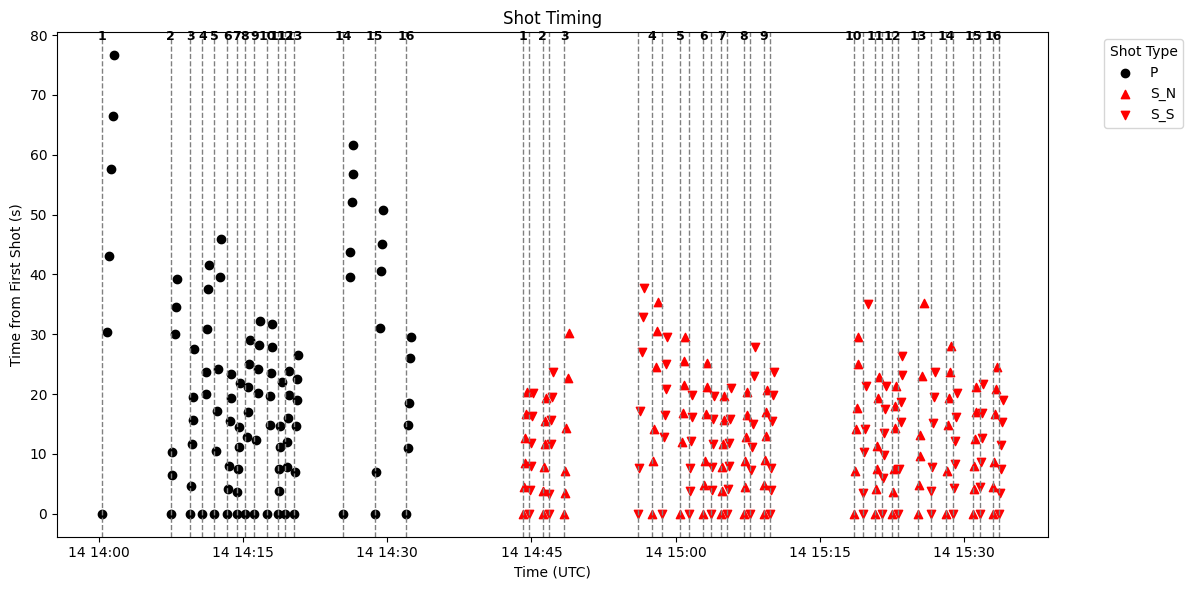

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Shot Timing'}, xlabel='Time (UTC)', ylabel='Time from First Shot (s)'>)

In [36]:
out_path = "shots_plot.png"
shots.to_csv("shots_labeled.csv",index=False,date_format="%Y-%m-%d %H:%M:%S.%f")
plot_shot_data(shots, save_path=out_path, show=True)